In [3]:
import os
import scipy.io as sio
import pandas as pd

# Path to raw file
raw_file = "../data/raw/B0005.mat"
mat = sio.loadmat(raw_file)

# Access the battery struct
battery = mat['B0005'][0,0]
cycles = battery['cycle'][0]

print("Loaded", len(cycles), "total cycles from B0005.mat")


# Input + output folders
raw_file = "../data/raw/B0005.mat"
out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)

# Loop through cycles
cycle_csvs = []
for idx, c in enumerate(cycles):
    if c['type'][0] != 'discharge':
        continue
    
    time = c['data'][0,0]['Time'][0]
    current = c['data'][0,0]['Current_measured'][0]
    voltage = c['data'][0,0]['Voltage_measured'][0]
    temp = c['data'][0,0]['Temperature_measured'][0]

    df_cycle = pd.DataFrame({
        "time_s": time,
        "current_A": current,
        "voltage_V": voltage,
        "temp_C": temp,
        "cycle_number": idx+1
    })

    # Save each cycle
    out_path = os.path.join(out_dir, f"B0005_cycle_{idx+1}.csv")
    df_cycle.to_csv(out_path, index=False)
    cycle_csvs.append(out_path)

print(f"Saved {len(cycle_csvs)} discharge cycles to {out_dir}")

Loaded 616 total cycles from B0005.mat
Saved 168 discharge cycles to ../data/processed


In [4]:
meta = {
    "battery_type": "18650 Li-ion (NMC)",
    "mass_kg": 0.045,
    "Cp_J_per_kgK": 900,
    "surface_area_m2": 0.021,
    "note": "h and R are cycle-dependent, fitted from thermal model",
    "source": "Assumed from literature + Week 1 fits"
}

os.makedirs("../data/meta", exist_ok=True)
pd.DataFrame([meta]).to_csv("../data/meta/assumptions.csv", index=False)

print("Saved assumptions to ../data/meta/assumptions.csv")


Saved assumptions to ../data/meta/assumptions.csv


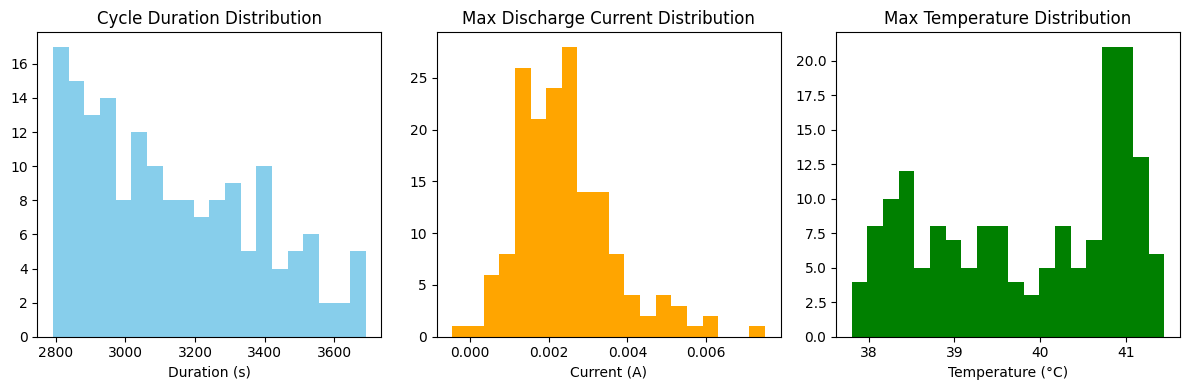

In [5]:
import matplotlib.pyplot as plt
import glob

# Load all processed discharge cycles
all_files = glob.glob("../data/processed/B0005_cycle_*.csv")
dfs = [pd.read_csv(f) for f in all_files]
df_all = pd.concat(dfs, ignore_index=True)

# Cycle durations
cycle_durations = df_all.groupby("cycle_number")["time_s"].max()

# Max temperatures per cycle
max_temps = df_all.groupby("cycle_number")["temp_C"].max()

# Max discharge current per cycle
max_currents = df_all.groupby("cycle_number")["current_A"].max()

# Plot histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(cycle_durations, bins=20, color='skyblue')
plt.title("Cycle Duration Distribution")
plt.xlabel("Duration (s)")

plt.subplot(1,3,2)
plt.hist(max_currents, bins=20, color='orange')
plt.title("Max Discharge Current Distribution")
plt.xlabel("Current (A)")

plt.subplot(1,3,3)
plt.hist(max_temps, bins=20, color='green')
plt.title("Max Temperature Distribution")
plt.xlabel("Temperature (°C)")

plt.tight_layout()
plt.show()


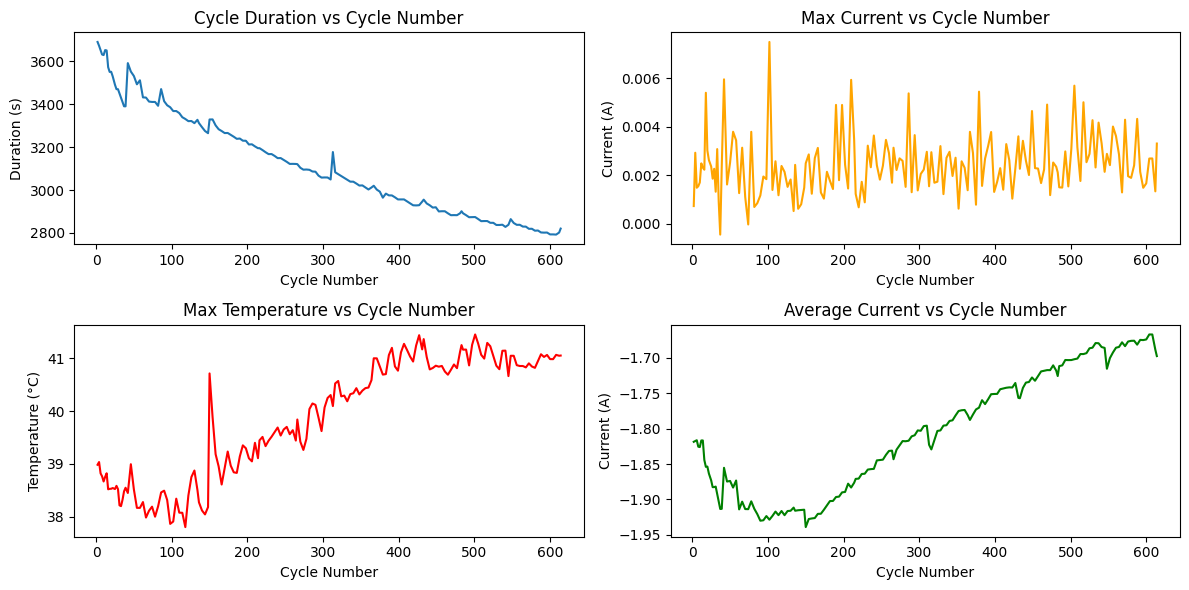

In [6]:
# Evolution of cycle metrics
cycle_durations = df_all.groupby("cycle_number")["time_s"].max()
max_temps = df_all.groupby("cycle_number")["temp_C"].max()
max_currents = df_all.groupby("cycle_number")["current_A"].max()
avg_currents = df_all.groupby("cycle_number")["current_A"].mean()

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
cycle_durations.plot()
plt.title("Cycle Duration vs Cycle Number")
plt.xlabel("Cycle Number")
plt.ylabel("Duration (s)")

plt.subplot(2,2,2)
max_currents.plot(color="orange")
plt.title("Max Current vs Cycle Number")
plt.xlabel("Cycle Number")
plt.ylabel("Current (A)")

plt.subplot(2,2,3)
max_temps.plot(color="red")
plt.title("Max Temperature vs Cycle Number")
plt.xlabel("Cycle Number")
plt.ylabel("Temperature (°C)")

plt.subplot(2,2,4)
avg_currents.plot(color="green")
plt.title("Average Current vs Cycle Number")
plt.xlabel("Cycle Number")
plt.ylabel("Current (A)")

plt.tight_layout()
plt.show()


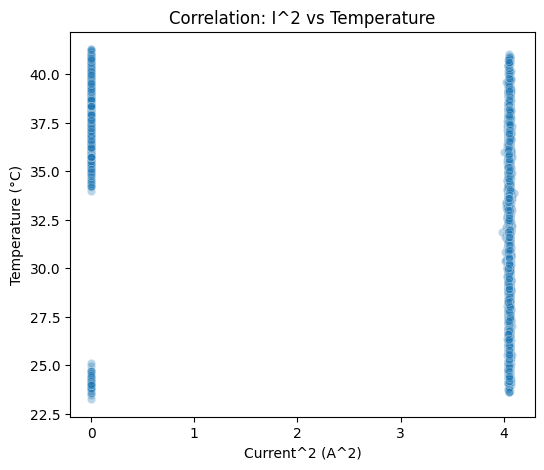

In [7]:
import seaborn as sns

# Sample subset for speed
df_sample = df_all.sample(5000, random_state=42)

plt.figure(figsize=(6,5))
sns.scatterplot(x=df_sample["current_A"]**2, y=df_sample["temp_C"], alpha=0.3)
plt.xlabel("Current^2 (A^2)")
plt.ylabel("Temperature (°C)")
plt.title("Correlation: I^2 vs Temperature")
plt.show()
